BERT 优化版本 - 社交媒体虚假信息检测

【1】加载本地BERT模型...
模型文件夹内容：['config.json', 'pytorch_model.bin', 'vocab.txt']


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: C:\Users\86187\bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ 模型加载成功！使用设备：cpu

【2】加载数据...
总数据量：9592
列名：['content', 'label', 'category']

【3】文本清洗...
✅ 文本清洗完成
清洗前示例：【三星折叠屏原型机曝光：双屏设计/非柔性屏】网友@黎启lee晒出三星的ProjcetV可折叠手机，该机型号为SM-G92...
清洗后示例：三星折叠屏原型机曝光 双屏设计 非柔性屏 网友 该机型号为SM G929 采用了双屏幕设计 仅用物理方式连接起来 非柔性...

【4】提取BERT特征...
使用 9592 条样本（可修改sample_size跑全部数据）


提取BERT特征: 100%|████████████████████████████████████████████████████████████████| 1199/1199 [21:51<00:00,  1.09s/it]


✅ BERT特征维度：(9592, 768)

【5】提取category特征...
category类别数：10
✅ category特征维度：(9592, 10)

【6】特征拼接...
总特征维度：(9592, 778)
真实样本数：4951
虚假样本数：4641

【7】划分训练集和测试集...
训练集：7673 样本
测试集：1919 样本

【8】训练XGBoost模型...
✅ 模型训练完成！

【9】模型评估...

🎯 测试集准确率：0.8317 (83.17%)

混淆矩阵：
[[828 161]
 [162 768]]

分类报告：
              precision    recall  f1-score   support

          真实       0.84      0.84      0.84       989
          虚假       0.83      0.83      0.83       930

    accuracy                           0.83      1919
   macro avg       0.83      0.83      0.83      1919
weighted avg       0.83      0.83      0.83      1919


【10】绘制混淆矩阵图...


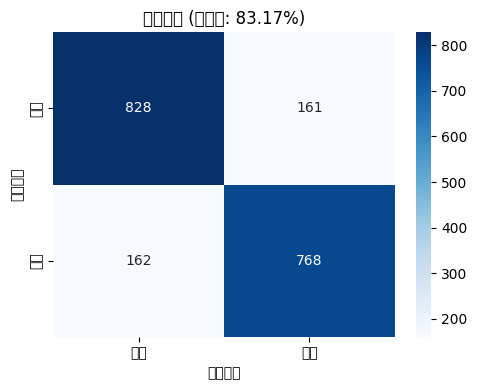

✅ 图片已保存为 confusion_matrix.png

【11】绘制特征重要性图...


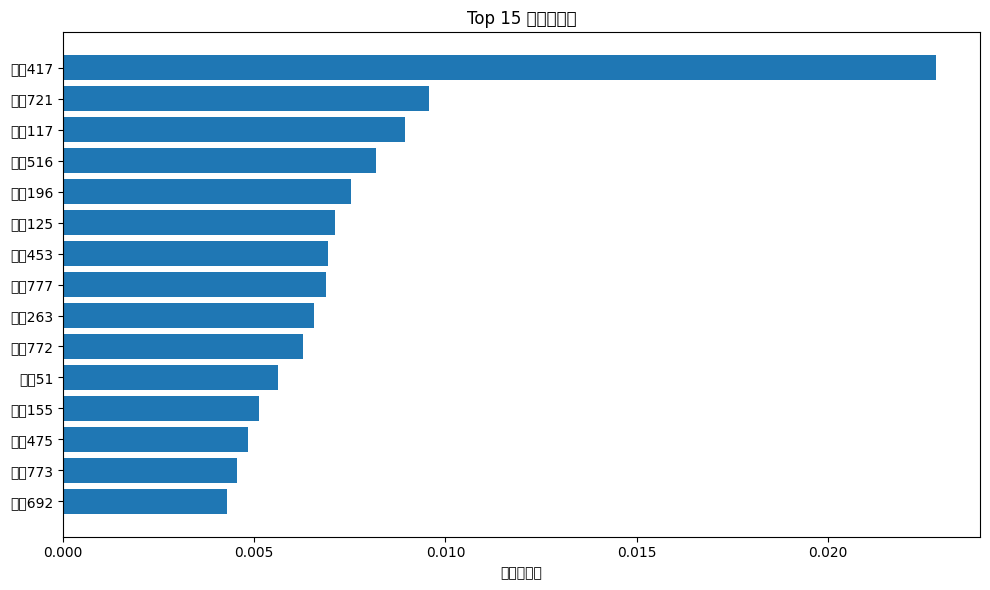

✅ 图片已保存为 feature_importance.png

【12】保存模型...
✅ 模型已保存为 fake_news_model.pkl

✅ 全部完成！


In [29]:
import torch
from transformers import BertTokenizer, BertModel
import numpy as np
import pandas as pd
import pickle
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import xgboost as xgb
from tqdm import tqdm
import warnings
import os

warnings.filterwarnings('ignore')

print("=" * 60)
print("BERT 优化版本 - 社交媒体虚假信息检测")
print("=" * 60)

# ============================================================
# 1. 加载本地BERT模型
# ============================================================
print("\n【1】加载本地BERT模型...")
model_path = r'C:\Users\86187\bert-base-chinese'

# 检查模型文件是否存在
if not os.path.exists(model_path):
    print(f"错误：模型文件夹不存在！请将模型文件放到 {model_path}")
else:
    files = os.listdir(model_path)
    print(f"模型文件夹内容：{files}")
    
tokenizer = BertTokenizer.from_pretrained(model_path, local_files_only=True)
model = BertModel.from_pretrained(model_path, local_files_only=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()
print(f"✅ 模型加载成功！使用设备：{device}")

# ============================================================
# 2. 加载数据
# ============================================================
print("\n【2】加载数据...")
with open('data/train.pkl', 'rb') as f:
    df_train = pickle.load(f)
with open('data/val.pkl', 'rb') as f:
    df_val = pickle.load(f)
with open('data/test.pkl', 'rb') as f:
    df_test = pickle.load(f)

df = pd.concat([df_train, df_val, df_test], ignore_index=True)
print(f"总数据量：{len(df)}")
print(f"列名：{df.columns.tolist()}")

# ============================================================
# 3. 文本清洗
# ============================================================
print("\n【3】文本清洗...")
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'http\S+', '', text)           # 去除URL
    text = re.sub(r'@\w+', '', text)              # 去除@提及
    text = re.sub(r'[^\u4e00-\u9fa5a-zA-Z0-9]', ' ', text)  # 保留中英文数字
    return text.strip()

df['clean_text'] = df['content'].apply(clean_text)
print("✅ 文本清洗完成")
print(f"清洗前示例：{df['content'].iloc[0][:60]}...")
print(f"清洗后示例：{df['clean_text'].iloc[0][:60]}...")

# ============================================================
# 4. 提取BERT特征
# ============================================================
print("\n【4】提取BERT特征...")

def get_bert_vectors(texts, batch_size=8):
    """批量提取BERT的[CLS]向量"""
    vectors = []
    for i in tqdm(range(0, len(texts), batch_size), desc="提取BERT特征"):
        batch_texts = texts[i:i+batch_size].tolist()
        inputs = tokenizer(batch_texts, return_tensors='pt', padding=True, truncation=True, max_length=128)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
            cls_vectors = outputs.last_hidden_state[:, 0, :]  # [CLS]向量
        vectors.append(cls_vectors.cpu().numpy())
    return np.concatenate(vectors, axis=0)

# 全部数据测试
sample_size = len(df)
print(f"使用 {sample_size} 条样本（可修改sample_size跑全部数据）")
df_sample = df.sample(n=sample_size, random_state=42).reset_index(drop=True)

X_bert = get_bert_vectors(df_sample['clean_text'])
print(f"✅ BERT特征维度：{X_bert.shape}")

# ============================================================
# 5. 提取category特征
# ============================================================
print("\n【5】提取category特征...")
ohe = OneHotEncoder(sparse_output=False)
X_category = ohe.fit_transform(df_sample[['category']])
print(f"category类别数：{len(ohe.categories_[0])}")
print(f"✅ category特征维度：{X_category.shape}")

# ============================================================
# 6. 特征拼接
# ============================================================
print("\n【6】特征拼接...")
X = np.concatenate([X_bert, X_category], axis=1)
y = df_sample['label'].values
print(f"总特征维度：{X.shape}")
print(f"真实样本数：{(y==0).sum()}")
print(f"虚假样本数：{(y==1).sum()}")

# ============================================================
# 7. 划分数据集
# ============================================================
print("\n【7】划分训练集和测试集...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"训练集：{len(X_train)} 样本")
print(f"测试集：{len(X_test)} 样本")

# ============================================================
# 8. 训练XGBoost模型
# ============================================================
print("\n【8】训练XGBoost模型...")
model_xgb = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

model_xgb.fit(X_train, y_train)
print("✅ 模型训练完成！")

# ============================================================
# 9. 模型评估
# ============================================================
print("\n【9】模型评估...")
y_pred = model_xgb.predict(X_test)

# 转换类型避免报错
y_test_int = y_test.astype(np.int64)
y_pred_int = y_pred.astype(np.int64)

acc = accuracy_score(y_test_int, y_pred_int)
print(f"\n🎯 测试集准确率：{acc:.4f} ({acc*100:.2f}%)")

# 混淆矩阵
cm = confusion_matrix(y_test_int, y_pred_int)
print(f"\n混淆矩阵：")
print(cm)

# 分类报告
print(f"\n分类报告：")
print(classification_report(y_test_int, y_pred_int, target_names=['真实', '虚假']))

# ============================================================
# 10. 绘制混淆矩阵图
# ============================================================
print("\n【10】绘制混淆矩阵图...")
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['真实', '虚假'], 
            yticklabels=['真实', '虚假'])
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.title(f'混淆矩阵 (准确率: {acc:.2%})')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ 图片已保存为 confusion_matrix.png")

# ============================================================
# 11. 特征重要性图
# ============================================================
print("\n【11】绘制特征重要性图...")
importance = model_xgb.feature_importances_
top_n = 15
indices = importance.argsort()[-top_n:]

plt.figure(figsize=(10, 6))
plt.barh(range(top_n), importance[indices])
plt.yticks(range(top_n), [f'特征{i}' for i in indices])
plt.xlabel('特征重要性')
plt.title(f'Top {top_n} 特征重要性')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("✅ 图片已保存为 feature_importance.png")

# ============================================================
# 12. 保存模型
# ============================================================
print("\n【12】保存模型...")
import joblib
joblib.dump(model_xgb, 'fake_news_model.pkl')
joblib.dump(tokenizer, 'bert_tokenizer.pkl')
joblib.dump(ohe, 'category_encoder.pkl')
print("✅ 模型已保存为 fake_news_model.pkl")

print("\n" + "=" * 60)
print("✅ 全部完成！")
print("=" * 60)